<a href="https://colab.research.google.com/github/ajaynice1996/DIY_MRI_Workshop_II_Recon/blob/main/Day2_Notebook_1_3_ZS_N2N_hf_only.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Zero-Shot Noise2Noise: Efficient Image Denoising without any Data**


This repository provides a demonstration of how to use our proposed ZS-N2N (Zero-Shot Noise2Noise) algorithm to denoise images without any training data or a noise model or level as input. The notebook is Pytorch based.

The method is as simple as convolving the noisy image with two fixed kernels to create a pair of downsampled images. A simple 2 layer CNN is then trained with a consistency loss to map one downsampled image to the other.

The notebook can easily be run on GPU or CPU. Choose the device to be 'cuda' if you want to run on GPU, otherwise choose 'cpu'. If you choose 'cuda' remember to change your colab runtime to GPU via 'Runtime' -> 'Change runtime type'.



It is recommended to normalize the pixel range of the images to 0-1, as this is the range the hyperparameters and initialization of the network were tested with.

The network's size was optimized for images of size 256x256. If you have smaller or larger images, you might want to decrease or increase the network's size. This can be done by changing the variable "chan_embed".

The 20 test images from SIDD and PolyU can be found here: https://drive.google.com/file/d/1oJ2wIMPAxK353Shz5kW0Xg-KXmwUwYZR/ .
They are normalized and converted to Pytorch tensors, and can be loaded with torch.load('file_name').

In [ ]:
from google.colab import drive
drive.mount('/drive')

Mounted at /drive


In [1]:
!git clone https://github.com/ajaynice1996/DIY_MRI_Workshop_II_Recon

Cloning into 'DIY_MRI_Workshop_II_Recon'...
remote: Enumerating objects: 231, done.
remote: Counting objects: 100% (122/122), done.
remote: Compressing objects: 100% (112/112), done.
remote: Total 231 (delta 56), reused 24 (delta 8), pack-reused 109 (from 2)
Receiving objects: 100% (231/231), 131.65 MiB | 33.52 MiB/s, done.
Resolving deltas: 100% (69/69), done.


In [2]:
!pwd

/content


In [3]:
#Enter device here, 'cuda' for GPU, and 'cpu' for CPU
device = 'cuda'

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

Successfully loaded POCEMR001_T2.nii.gz
Image dimensions (voxels): (224, 224, 160)
Voxel dimensions (resolution in mm): (np.float32(1.0), np.float32(1.0), np.float32(1.0))

Min value of numpy slice (before tensor conversion): 0.0000
Max value of numpy slice (before tensor conversion): 255.0000
Note: Normalizing numpy slice to 0-1 range for tensor conversion.
Shape of the prepared clean_img (torch tensor - B C H W): torch.Size([1, 1, 224, 224])
Min value of clean_img (torch tensor): 0.0000
Max value of clean_img (torch tensor): 1.0000


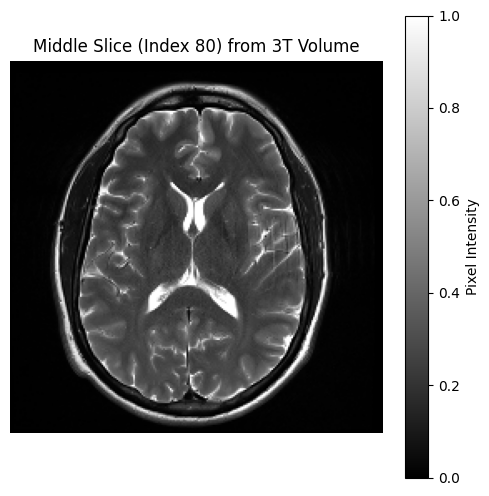

In [5]:
import nibabel as nib
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

# Define the base path to the folder in Google Drive
base_path = '/content/DIY_MRI_Workshop_II_Recon/data/Training_data/POCEMR001/3T'

# Assuming the t2w image is named 't2w_image.nii.gz' as a common convention.
# If the exact filename is different, please update 'image_filename'.
image_filename = 'POCEMR001_T2.nii.gz'

# Construct the full path to the image file
image_path = os.path.join(base_path, image_filename)

# Load the NIfTI image and extract information
try:
    nifti_img = nib.load(image_path)
    clean_volume = nifti_img.get_fdata()
    header = nifti_img.header
    voxel_dims = header.get_zooms()

    print(f"Successfully loaded {image_filename}")
    print(f"Image dimensions (voxels): {clean_volume.shape}")
    print(f"Voxel dimensions (resolution in mm): {voxel_dims}")
    # You can uncomment these lines to print more header info if needed
    # print(f"Data type: {header.get_data_dtype()}")
    # print(f"Affine transformation:\n{nifti_img.affine}")

    # Extract a middle slice from the 3D volume
    slice_index = clean_volume.shape[2] // 2
    clean_img_np_slice = clean_volume[:, :, slice_index]

    print(f"\nMin value of numpy slice (before tensor conversion): {clean_img_np_slice.min():.4f}")
    print(f"Max value of numpy slice (before tensor conversion): {clean_img_np_slice.max():.4f}")

    # Normalize the slice to 0-1 range for tensor conversion if its not already
    if clean_img_np_slice.max() > 1.0 or clean_img_np_slice.min() < 0.0:
        print("Note: Normalizing numpy slice to 0-1 range for tensor conversion.")
        clean_img_np_slice = (clean_img_np_slice - clean_img_np_slice.min()) / (clean_img_np_slice.max() - clean_img_np_slice.min())

    # Convert the numpy array slice to a PyTorch tensor
    # Add a channel dimension (C=1 for grayscale) and a batch dimension (B=1)
    # This will be the 'clean_img' used by the rest of the notebook
    clean_img = torch.from_numpy(clean_img_np_slice).float().unsqueeze(0).unsqueeze(0)

    print(f"Shape of the prepared clean_img (torch tensor - B C H W): {clean_img.shape}")
    print(f"Min value of clean_img (torch tensor): {clean_img.min():.4f}")
    print(f"Max value of clean_img (torch tensor): {clean_img.max():.4f}")

    # Display the middle slice as a grayscale image
    plt.figure(figsize=(6, 6))
    plt.imshow(clean_img_np_slice.T, cmap='gray', origin = 'lower')
    plt.title(f'Middle Slice (Index {slice_index}) from 3T Volume')
    plt.colorbar(label='Pixel Intensity')
    plt.axis('off') # Hide axes ticks for cleaner display
    plt.show()

except FileNotFoundError:
    print(f"Error: The file {image_path} was not found. Please check the path and filename.")
except Exception as e:
    print(f"An error occurred while loading or processing the image: {e}")

Add noise to the image

In [6]:
noise_type = 'gauss' # Either 'gauss' or 'poiss'
noise_level = 50     # Pixel range is 0-255 for Gaussian, and 0-1 for Poission

def add_noise(x,noise_level):

    if noise_type == 'gauss':
        noisy = x + torch.normal(0, noise_level/255, x.shape)
        noisy = torch.clamp(noisy,0,1)

    elif noise_type == 'poiss':
        noisy = torch.poisson(noise_level * x)/noise_level

    return noisy

noisy_img = add_noise(clean_img, noise_level)

In [7]:
clean_img = clean_img.to(device)
noisy_img = noisy_img.to(device)

We next define our network, which is a 2 layer CNN

In [8]:
class network(nn.Module):
    def __init__(self,n_chan,chan_embed=48):
        super(network, self).__init__()

        self.act = nn.LeakyReLU(negative_slope=0.2, inplace=True)
        self.conv1 = nn.Conv2d(n_chan,chan_embed,3,padding=1)
        self.conv2 = nn.Conv2d(chan_embed, chan_embed, 3, padding = 1)
        self.conv3 = nn.Conv2d(chan_embed, n_chan, 1)

    def forward(self, x):
        x = self.act(self.conv1(x))
        x = self.act(self.conv2(x))
        x = self.conv3(x)

        return x

n_chan = clean_img.shape[1]
model = network(n_chan)
model = model.to(device)
print("The number of parameters of the network is: ",  sum(p.numel() for p in model.parameters() if p.requires_grad))

The number of parameters of the network is:  21313


We next introduce the image pair downsampler which outputs two downsampled images of half the spatial resolution by averaging diagonal pixels in non-overlapping patches, as shown in the below figure.

It is realised by convolving the image with the 2 fixed kernels: $k_1 = \begin{bmatrix}0 & 0.5 \\0.5 & 0\end{bmatrix}$ and $k_2 = \begin{bmatrix}0.5 & 0 \\0 & 0.5\end{bmatrix}$, where the convolution has stride=2, and is applied to each image channel separately.

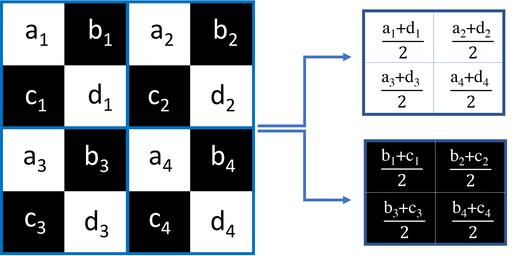

In [9]:
def pair_downsampler(img):
    #img has shape B C H W
    c = img.shape[1]

    filter1 = torch.FloatTensor([[[[0 ,0.5],[0.5, 0]]]]).to(img.device)
    filter1 = filter1.repeat(c,1, 1, 1)

    filter2 = torch.FloatTensor([[[[0.5 ,0],[0, 0.5]]]]).to(img.device)
    filter2 = filter2.repeat(c,1, 1, 1)

    output1 = F.conv2d(img, filter1, stride=2, groups=c)
    output2 = F.conv2d(img, filter2, stride=2, groups=c)

    return output1, output2

Display noisy image and its corresponding downsampled pair. Note how the downsampled images have half the spatial resolution.

Text(0.5, 1.0, 'Second downsampled')

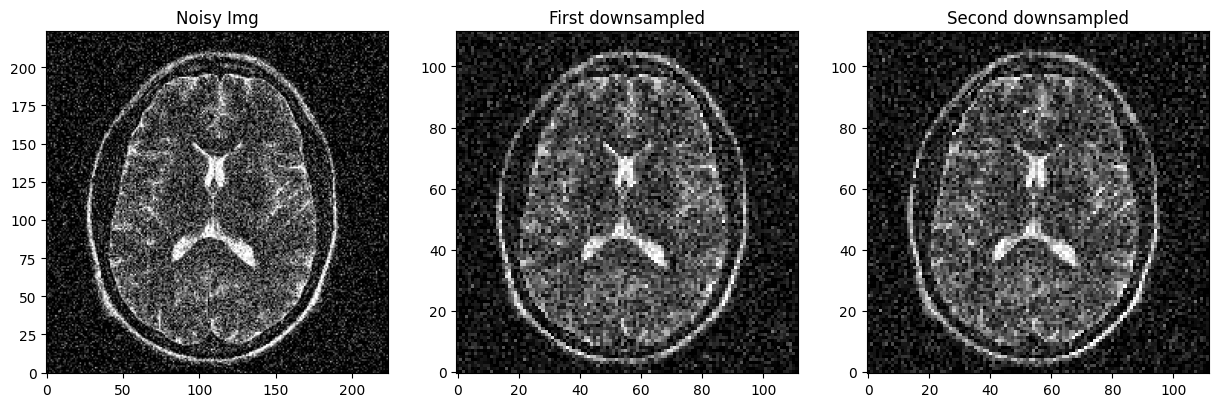

In [10]:
img1, img2 = pair_downsampler(noisy_img)

img0 = noisy_img.cpu().squeeze(0).permute(1,2,0)
img1 = img1.cpu().squeeze(0).permute(1,2,0)
img2 = img2.cpu().squeeze(0).permute(1,2,0)

fig, ax = plt.subplots(1, 3,figsize=(15, 15))

ax[0].imshow(img0.squeeze().T, cmap = 'gray', origin = 'lower')
ax[0].set_title('Noisy Img')

ax[1].imshow(img1.squeeze().T ,cmap = 'gray', origin = 'lower')
ax[1].set_title('First downsampled')

ax[2].imshow(img2.squeeze().T, cmap = 'gray', origin = 'lower')
ax[2].set_title('Second downsampled')

The loss function is the sum of a residual loss plus a consistency loss as follows:

$$     \mathcal{L}_\mathrm{res.}(\theta) =\frac{1}{2}\left( \|D_1({y}) - f_{\theta}(D_1({y})) - D_2({y})\|_2^2 + \|D_2({y}) - f_{\theta}(D_2({y})) - D_1({y})\|_2^2 \right). $$

$$     \mathcal{L}_\mathrm{cons.}(\theta) = \frac{1}{2} \left( \|f_{\theta}(D_1({y})) - D_1(f_{\theta}({y}))\|_2^2 + \|f_{\theta}(D_2({y})) - D_2(f_{\theta}({y}))\|_2^2 \right). $$

$$ \mathcal{L}(\theta) = \mathcal{L}_\mathrm{res.}(\theta) + \mathcal{L}_\mathrm{cons.}(\theta), $$

where $y$ is the noisy input image, $D$ is the image pair downsampler, and $f_\theta$ is the network.


In [11]:
def mse(gt: torch.Tensor, pred:torch.Tensor)-> torch.Tensor:
    loss = torch.nn.MSELoss()
    return loss(gt,pred)

def loss_func(noisy_img):
    noisy1, noisy2 = pair_downsampler(noisy_img)

    pred1 =  noisy1 - model(noisy1)
    pred2 =  noisy2 - model(noisy2)

    loss_res = 1/2*(mse(noisy1,pred2)+mse(noisy2,pred1))

    noisy_denoised =  noisy_img - model(noisy_img)
    denoised1, denoised2 = pair_downsampler(noisy_denoised)

    loss_cons=1/2*(mse(pred1,denoised1) + mse(pred2,denoised2))

    loss = loss_res + loss_cons

    return loss

Train, test, and denoise functions

In [12]:
def train(model, optimizer, noisy_img):

  loss = loss_func(noisy_img)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  return loss.item()

def test(model, noisy_img, clean_img):

    with torch.no_grad():
        pred = torch.clamp(noisy_img - model(noisy_img),0,1)
        MSE = mse(clean_img, pred).item()
        PSNR = 10*np.log10(1/MSE)

    return PSNR

def denoise(model, noisy_img):

    with torch.no_grad():
        pred = torch.clamp( noisy_img - model(noisy_img),0,1)

    return pred

Optimizer and Hyperparameters

In [14]:
max_epoch = 200     # training epochs
lr = 0.001           # learning rate
step_size = 1000     # number of epochs at which learning rate decays
gamma = 0.5          # factor by which learning rate decays

optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)

Start denoising

In [15]:
for epoch in tqdm(range(max_epoch)):
    train(model, optimizer, noisy_img)
    scheduler.step()

  0%|          | 0/200 [00:00<?, ?it/s]

PSNR of denoised image

In [16]:
PSNR = test(model, noisy_img, clean_img)
print(PSNR)

20.570501630678937


Display clean, noisy, and denoised images.

In [17]:
denoised_img = denoise(model, noisy_img)

denoised = denoised_img.cpu().squeeze(0).permute(1,2,0)
clean = clean_img.cpu().squeeze(0).permute(1,2,0)
noisy = noisy_img.cpu().squeeze(0).permute(1,2,0)

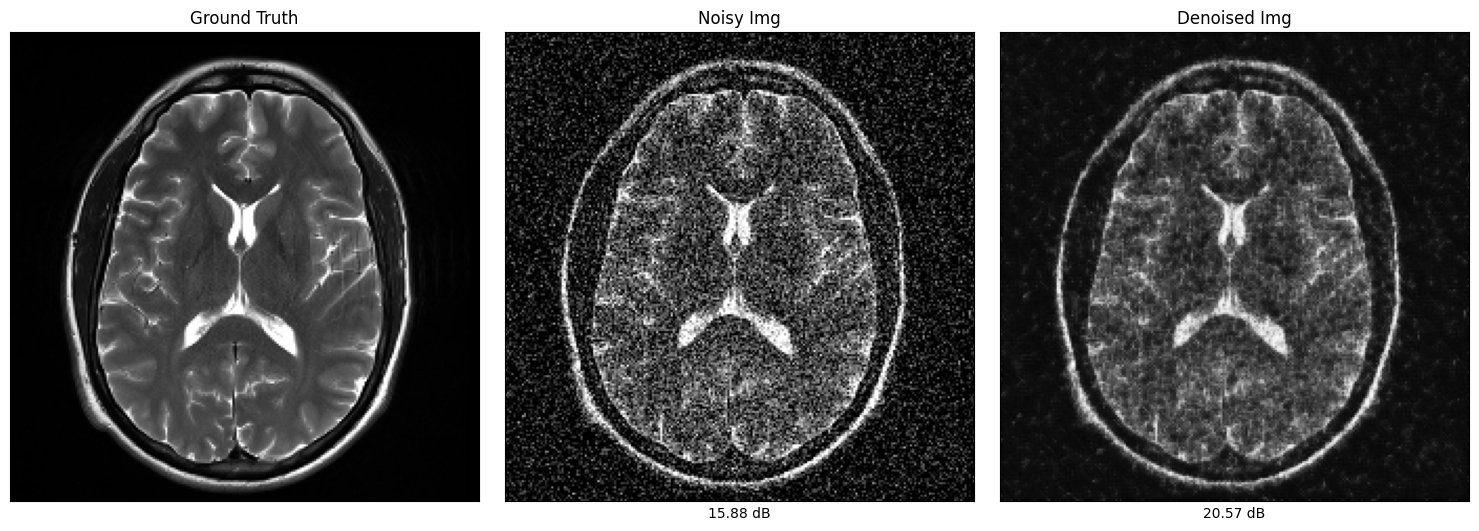

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Convert tensors to 2D NumPy arrays for plotting
def to_image(x):
    if torch.is_tensor(x):
        x = x.detach().cpu()
        x = x.squeeze()
        x = x.numpy()
    else:
        x = np.asarray(x)
        x = np.squeeze(x)
    return x


clean_plot = to_image(clean)
noisy_plot = to_image(noisy)
denoised_plot = to_image(denoised)

# PSNR
noisy_mse = mse(noisy, clean).item()
denoised_mse = mse(denoised, clean).item()

noisy_psnr = 10 * np.log10(1 / noisy_mse)
denoised_psnr = 10 * np.log10(1 / denoised_mse)

# Plot
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Ground Truth
ax[0].imshow(clean_plot.T, cmap='gray', origin='lower')
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title('Ground Truth')

# Noisy
ax[1].imshow(noisy_plot.T, cmap='gray', origin='lower')
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_title('Noisy Img')
ax[1].set_xlabel(f'{noisy_psnr:.2f} dB')

# Denoised
ax[2].imshow(denoised_plot.T, cmap='gray', origin='lower')
ax[2].set_xticks([])
ax[2].set_yticks([])
ax[2].set_title('Denoised Img')
ax[2].set_xlabel(f'{denoised_psnr:.2f} dB')

plt.tight_layout()
plt.show()

In [ ]:
s